# PHẦN I: PIPELINE HUẤN LUYỆN & ĐÁNH GIÁ CHÍNH
Khu vực chứa pipeline thực thi chuẩn: nạp cấu hình, tiền xử lý, huấn luyện 4.000 steps và đánh giá hiệu năng mô hình.

## 1. Thiết lập Môi trường & Dependencies
Cài đặt các gói thư viện cần thiết phục vụ việc huấn luyện VietOCR và tính toán sai số khoảng cách ký tự (CER/WER).

In [1]:
# [Phần I - Cell 1] Cài đặt VietOCR không kèm phụ thuộc thừa (--no-deps) và các gói lõi
!pip install -q git+https://github.com/pbcquoc/vietocr.git --no-deps
!pip install -q einops prefetch_generator editdistance gdown pyyaml pillow torchvision lmdb

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.7/344.7 kB 5.9 MB/s eta 0:00:00:00:01


## 2. Cấu hình Đường dẫn Động (Low Coupling Config)
Quản lý tập trung các đường dẫn đầu vào/đầu ra. Mã nguồn tự động nhận biết môi trường thực thi (Kaggle hoặc Local), không hardcode đường dẫn tuyệt đối.

In [2]:
# [Phần I - Cell 2] Khởi tạo cấu hình đường dẫn động
import os
from pathlib import Path

IS_KAGGLE = Path('/kaggle').exists()

OUTPUT_DIR = Path('/kaggle/working') if IS_KAGGLE else Path('./output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if IS_KAGGLE:
    RAW_DATA_IMG_DIR = Path('/kaggle/input/datasets/trnchihong/viethandocr-data')
    RAW_SPLIT_DIR = Path('/kaggle/input/datasets/danhngnnguyn/results-updated/results')
else:
    RAW_DATA_IMG_DIR = Path('./data/viethandocr-data')
    RAW_SPLIT_DIR = Path('./data/results')

CONFIG_PATHS = {
    'raw_img_dir': RAW_DATA_IMG_DIR,
    'raw_train_txt': RAW_SPLIT_DIR / 'train_line.txt',
    'raw_val_txt': RAW_SPLIT_DIR / 'val_line.txt',
    'raw_test_txt': RAW_SPLIT_DIR / 'test_line.txt',
    # File nhãn sạch sau khi tiền xử lý và lọc truncation
    'clean_train_annotation': OUTPUT_DIR / 'clean_train_line.txt',
    'clean_val_annotation': OUTPUT_DIR / 'clean_val_line.txt',
    'checkpoint_dir': OUTPUT_DIR / 'checkpoints',
}

CONFIG_PATHS['checkpoint_dir'].mkdir(parents=True, exist_ok=True)
print("=== ĐÃ THIẾT LẬP XONG CẤU HÌNH ĐƯỜNG DẪN ===")
print(f"Ảnh gốc:    {CONFIG_PATHS['raw_img_dir']}")
print(f"Train gốc:  {CONFIG_PATHS['raw_train_txt']}")
print(f"Val gốc:    {CONFIG_PATHS['raw_val_txt']}")
print(f"Thư mục ra: {OUTPUT_DIR}")

=== ĐÃ THIẾT LẬP XONG CẤU HÌNH ĐƯỜNG DẪN ===
Ảnh gốc:    /kaggle/input/datasets/trnchihong/viethandocr-data
Train gốc:  /kaggle/input/datasets/danhngnnguyn/results-updated/results/train_line.txt
Val gốc:    /kaggle/input/datasets/danhngnnguyn/results-updated/results/val_line.txt
Thư mục ra: /kaggle/working


## 3. Tiền Xử Lý Dữ Liệu & Chuẩn Hóa Tệp Nhãn Sạch
Giải mã các chuỗi nhãn theo chuẩn RFC 4180 (xử lý triệt để dấu ngoặc kép thừa), ghép đường dẫn ảnh đầy đủ và lưu thành các tệp nhãn sạch phục vụ huấn luyện.

In [4]:
# [Phần I - Cell 3] Tạo tệp nhãn sạch cho tập Train và Validation
import csv
from pathlib import Path

raw_img_dir = CONFIG_PATHS['raw_img_dir']
splits = [
    (CONFIG_PATHS['raw_train_txt'], CONFIG_PATHS['clean_train_annotation']),
    (CONFIG_PATHS['raw_val_txt'], CONFIG_PATHS['clean_val_annotation'])
]

def generate_clean_annotations(src_path, dest_path):
    print(f"Đang xử lý: {src_path.name} -> {dest_path.name}...")
    valid_records = 0
    
    with open(src_path, 'r', encoding='utf-8') as f_in, \
         open(dest_path, 'w', encoding='utf-8') as f_out:
        
        reader = csv.reader(f_in, delimiter='\t')
        for row in reader:
            if not row or len(row) < 2:
                continue
            
            rel_path, label = row[0].strip(), row[1].strip()
            if not label:
                continue
            
            full_img_path = (raw_img_dir / rel_path).resolve()
            
            # Ghi định dạng chuẩn của VietOCR: <full_image_path>\t<clean_label>\n
            f_out.write(f"{full_img_path}\t{label}\n")
            valid_records += 1
            
    print(f"-> Hoàn tất: {valid_records:,} mẫu hợp lệ được ghi nhận.")

for src, dest in splits:
    generate_clean_annotations(src, dest)

Đang xử lý: train_line.txt -> clean_train_line.txt...
-> Hoàn tất: 6,297 mẫu hợp lệ được ghi nhận.
Đang xử lý: val_line.txt -> clean_val_line.txt...
-> Hoàn tất: 731 mẫu hợp lệ được ghi nhận.


## 4. Thiết Lập Cấu Hình Mô Hình & Huấn Luyện (4.000 Steps)
Dọn dẹp cache cũ, nạp kiến trúc `vgg_transformer` thông qua class Cfg chuẩn, gán các siêu tham số huấn luyện và checkpoint an toàn trong thư mục working.

In [5]:
# [Phần I - Cell 4] Thiết lập cấu hình Trainer chuẩn
import glob
import os
import shutil
import torch
from vietocr.tool.config import Cfg

# 1. Bảo hiểm I/O: Xóa sạch cache LMDB tạm thời nếu còn sót lại
for item in glob.glob('/kaggle/working/*_hw') + glob.glob('./*_hw'):
    if os.path.exists(item):
        shutil.rmtree(item, ignore_errors=True)
        print(f"✓ Đã dọn dẹp cache LMDB cũ: {item}")

# 2. Nạp cấu hình mẫu chuẩn vgg_transformer
config = Cfg.load_config_from_name('vgg_transformer')

# 3. Thiết bị tính toán
config['device'] = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# 4. Cấu hình Dataset (Low-coupling qua CONFIG_PATHS)
config['dataset']['data_root'] = ''  # Chuỗi rỗng vì file clean đã chứa đường dẫn tuyệt đối
config['dataset']['train_annotation'] = str(CONFIG_PATHS['clean_train_annotation'])
config['dataset']['valid_annotation'] = str(CONFIG_PATHS['clean_val_annotation'])

# Chuẩn hoá kích thước dòng chữ
config['dataset']['image_max_width'] = 1024
config['dataset']['image_min_width'] = 32
config['dataset']['image_height'] = 32

# Tránh lỗi tràn shared memory trên môi trường ảo hóa Linux của Kaggle
config['dataloader'] = {'num_workers': 0}

# 5. Cấu hình Checkpoint an toàn
config['trainer']['save_dir'] = str(CONFIG_PATHS['checkpoint_dir'])
config['trainer']['checkpoint'] = str(CONFIG_PATHS['checkpoint_dir'] / 'best_val_checkpoint.pth')
config['trainer']['export'] = str(CONFIG_PATHS['checkpoint_dir'] / 'vgg_transformer_final.pth')

# 6. Siêu tham số huấn luyện hướng tới mốc 4.000 steps
config['trainer']['iters'] = 4000          # Tăng từ 1.500 lên 4.000 steps
config['trainer']['batch_size'] = 32       # Tối ưu cho VRAM 16GB của T4
config['trainer']['lr'] = 1e-4             # Learning rate chuẩn cho fine-tuning
config['trainer']['log_interval'] = 50     # In log train loss sau mỗi 50 steps
config['trainer']['valid_interval'] = 500  # Đánh giá val loss mỗi 500 steps
config['trainer']['print'] = True

print("✓ Đã cấu hình Trainer hoàn tất. Sẵn sàng khởi tạo phiên huấn luyện!")

✓ Đã cấu hình Trainer hoàn tất. Sẵn sàng khởi tạo phiên huấn luyện!


In [6]:
# [Phần I - Cell 5] Khởi tạo Trainer và kích hoạt Huấn luyện
from vietocr.model.trainer import Trainer

print(f"Đang khởi tạo Trainer trên thiết bị: {config['device']}...")
trainer = Trainer(config=config, pretrained=True)

print("Bắt đầu quá trình Huấn luyện 4.000 steps!")
trainer.train()

Đang khởi tạo Trainer trên thiết bị: cuda:0...
Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:02<00:00, 210MB/s]  
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(
18533it [00:12, 1462.89it/s]
Create train_data: 100%|████████████████████████████████████████| 6297/6297 [02:48<00:00, 37.26it/s]


Created dataset with 6296 samples


Create valid_data: 100%|██████████████████████████████████████████| 731/731 [00:22<00:00, 32.15it/s]


Created dataset with 730 samples


valid_data build cluster: 100%|███████████████████████████████| 730/730 [00:00<00:00, 130741.79it/s]

Bắt đầu quá trình Huấn luyện 4.000 steps!


iter: 000200 - train loss: 1.280 - lr: 1.57e-04 - load time: 67.93 - gpu time: 109.54
iter: 000400 - train loss: 0.993 - lr: 3.00e-04 - load time: 67.75 - gpu time: 108.30
iter: 000600 - train loss: 0.944 - lr: 2.98e-04 - load time: 67.21 - gpu time: 109.89
iter: 000800 - train loss: 0.896 - lr: 2.91e-04 - load time: 67.35 - gpu time: 107.45
iter: 001000 - train loss: 0.871 - lr: 2.80e-04 - load time: 66.06 - gpu time: 108.65
iter: 001200 - train loss: 0.865 - lr: 2.65e-04 - load time: 66.98 - gpu time: 108.70
iter: 001400 - train loss: 0.850 - lr: 2.46e-04 - load time: 67.90 - gpu time: 108.42
iter: 001600 - train loss: 0.843 - lr: 2.25e-04 - load time: 69.68 - gpu time: 109.04
iter: 001800 - train loss: 0.822 - lr: 2.01e-04 - load time: 70.83 - gpu time: 107.49
iter: 002000 - train loss: 0.822 - lr: 1.76e-04 - load time: 69.00 - gpu time: 109.50
iter: 002200 - train loss: 0.800 - lr: 1.50e-04 - load time: 67.38 - gpu time: 108.60
iter: 002400 - train loss: 0.809 - lr: 1.24e-04 - load

# PHẦN II: KHẢO SÁT, KIỂM THỬ & CHẨN ĐOÁN HỆ THỐNG
Khu vực chạy các bài kiểm tra thực nghiệm (Sanity Checks), dò tìm vị trí dữ liệu, phân tích nhãn rác (Truncation) và trực quan hóa lỗi (Error Analysis).

## 1. Kiểm tra Môi trường Phần cứng & Thư viện
Xác nhận trạng thái nhận diện GPU, dung lượng VRAM và phiên bản các thư viện lõi.

In [2]:
# [Phần II - Cell 1] Kiểm tra thông số GPU và import thư viện
import torch
import vietocr
import editdistance

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Trạng thái phần cứng:")
print(f" - Thiết bị tính toán: {device.upper()}")
if device == 'cuda':
    print(f" - GPU Model: {torch.cuda.get_device_name(0)}")
    print(f" - Dung lượng VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f" - VietOCR: Đã import thành công")

Trạng thái phần cứng:
 - Thiết bị tính toán: CPU
 - VietOCR: Đã import thành công


## 2. Khảo sát & Tự động Dò tìm Đường dẫn Dữ liệu
Dò tìm tự động thư mục dataset thực tế trong môi trường hiện tại, in danh sách tệp/thư mục con để phục vụ cấu hình cho Phần I.

In [10]:
# [Phần II - Cell 2] Khảo sát thư mục results-updated và đọc mẫu dữ liệu
import os
from pathlib import Path

RESULTS_DIR = Path('/kaggle/input/datasets/danhngnnguyn/results-updated/results')

print(f"Đường dẫn mục tiêu: {RESULTS_DIR}")
if RESULTS_DIR.exists():
    items = sorted(list(RESULTS_DIR.iterdir()))
    print(f"Tổng số tệp tin: {len(items)}")
    for item in items:
        print(f"  ├── [FILE] {item.name}")
        
    # Đọc thử 3 dòng đầu của train_line.txt
    sample_file = RESULTS_DIR / 'train_line.txt'
    if sample_file.exists():
        print(f"\n--- 3 dòng đầu của {sample_file.name} ---")
        with open(sample_file, 'r', encoding='utf-8') as f:
            for i in range(3):
                line = f.readline()
                if not line:
                    break
                print(f"Dòng {i+1}: {repr(line)}")
else:
    print("Lỗi: Không tìm thấy thư mục results tại đường dẫn trên.")

Đường dẫn mục tiêu: /kaggle/input/datasets/danhngnnguyn/results-updated/results
Tổng số tệp tin: 12
  ├── [FILE] test_all.txt
  ├── [FILE] test_line.txt
  ├── [FILE] test_paragraph.txt
  ├── [FILE] test_word.txt
  ├── [FILE] train_all.txt
  ├── [FILE] train_line.txt
  ├── [FILE] train_paragraph.txt
  ├── [FILE] train_word.txt
  ├── [FILE] val_all.txt
  ├── [FILE] val_line.txt
  ├── [FILE] val_paragraph.txt
  ├── [FILE] val_word.txt

--- 3 dòng đầu của train_line.txt ---
Dòng 1: 'UIT_HWDB_line/UIT_HWDB_line/train_data/248/1.jpg\tChuyện những người mang số 115. Sáng nay ngồi quán cà phê cóc, ông bạn già của tôi tâm sự :\n'
Dòng 2: 'UIT_HWDB_line/UIT_HWDB_line/train_data/248/2.jpg\t""" Chú mày biết không, hôm kia không nhờ cấp cứu đã xong cái mạng già này! ""."\n'
Dòng 3: 'UIT_HWDB_line/UIT_HWDB_line/train_data/248/3.jpg\tSố là trở về nhà sau một chầu nhậu, bị tăng huyết áp đột ngột, ông bị choáng ngất,\n'


## Khảo sát & Kiểm thử Dữ liệu Nhãn Line (Validation & Sanity Check)
Kiểm tra tính hợp lệ của đường dẫn ảnh vật lý trên ổ đĩa và rà soát các mẫu bị lỗi hoặc nhãn rỗng.

In [12]:
# [Phần II - Cell 3] Kiểm tra khớp đường dẫn ảnh và phát hiện nhãn bất thường
import os
from pathlib import Path

raw_img_dir = CONFIG_PATHS['raw_img_dir']
train_txt = CONFIG_PATHS['raw_train_txt']
val_txt = CONFIG_PATHS['raw_val_txt']

def verify_dataset(txt_path, max_checks=5):
    print(f"\n--- Đang kiểm tra: {txt_path.name} ---")
    if not txt_path.exists():
        print("Tệp không tồn tại!")
        return

    total_lines = 0
    missing_images = 0
    empty_labels = 0
    sample_checks = []

    with open(txt_path, 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f):
            total_lines += 1
            line = line.strip()
            if not line:
                continue
                
            parts = line.split('\t')
            rel_img = parts[0]
            label = parts[1] if len(parts) > 1 else ""

            if not label.strip():
                empty_labels += 1

            full_img_path = raw_img_dir / rel_img
            img_exists = full_img_path.exists()
            if not img_exists:
                missing_images += 1

            if len(sample_checks) < max_checks:
                sample_checks.append((img_exists, full_img_path, label))

    print(f"Tổng số mẫu: {total_lines:,}")
    print(f" - Số ảnh tồn tại hợp lệ: {total_lines - missing_images:,}")
    print(f" - Số ảnh thiếu/sai path: {missing_images}")
    print(f" - Số nhãn rỗng:          {empty_labels}")
    print("\nKiểm tra mẫu thực tế:")
    for exists, p, lbl in sample_checks:
        status = "OK" if exists else "KHÔNG TÌM THẤY"
        print(f" [{status}] {p.name} | Nhãn: {lbl[:40]}...")

verify_dataset(train_txt)
verify_dataset(val_txt)


--- Đang kiểm tra: train_line.txt ---
Tổng số mẫu: 6,297
 - Số ảnh tồn tại hợp lệ: 6,297
 - Số ảnh thiếu/sai path: 0
 - Số nhãn rỗng:          0

Kiểm tra mẫu thực tế:
 [OK] 1.jpg | Nhãn: Chuyện những người mang số 115. Sáng nay...
 [OK] 2.jpg | Nhãn: """ Chú mày biết không, hôm kia không nh...
 [OK] 3.jpg | Nhãn: Số là trở về nhà sau một chầu nhậu, bị t...
 [OK] 4.jpg | Nhãn: bà vợ luống cuống tay chân hét toáng lên...
 [OK] 5.jpg | Nhãn: "xin cấp cứu... Đó chỉ là một trong hàng...

--- Đang kiểm tra: val_line.txt ---
Tổng số mẫu: 731
 - Số ảnh tồn tại hợp lệ: 731
 - Số ảnh thiếu/sai path: 0
 - Số nhãn rỗng:          0

Kiểm tra mẫu thực tế:
 [OK] 1.jpg | Nhãn: 17 năm trên ốc đảo. Trên bãi đất bồi mà ...
 [OK] 2.jpg | Nhãn: lên như một ốc đảo hoang vu giữa bốn bề ...
 [OK] 3.jpg | Nhãn: lớn ở phía nam Thừa Thiên - Huế), đã ra ...
 [OK] 4.jpg | Nhãn: bờ đập, kênh mương, ao hồ công phu. Đó l...
 [OK] 5.jpg | Nhãn: gần 17 năm của Huỳnh Đỗi. Câu chuyện về ...


## Kiểm thử Bóc tách Dấu Ngoặc Kép & Chuẩn Hóa Chuỗi Nhãn
So sánh nhãn thô (bị lỗi nhân đôi ngoặc kép do chuẩn CSV RFC 4180) và nhãn sau khi được giải mã chuẩn xác bằng module csv.

In [13]:
# [Phần II - Cell 4] So sánh nhãn thô và nhãn sau khi unquote chuẩn CSV
import csv
from pathlib import Path

train_txt = CONFIG_PATHS['raw_train_txt']

def test_quote_unwrapping(file_path, sample_limit=5):
    print(f"=== SO SÁNH QUY TẮC DẤU NGOẶC KÉP TRÊN {file_path.name} ===")
    found = 0
    with open(file_path, 'r', encoding='utf-8') as f:
        # Sử dụng csv.reader với delimiter=\t để tự động xử lý quote/escape
        reader = csv.reader(f, delimiter='\t')
        for row in reader:
            if not row or len(row) < 2:
                continue
            path_part, label = row[0], row[1]
            
            # Chỉ tìm các dòng có chứa dấu ngoặc kép để đối chiếu
            if '"' in label:
                found += 1
                print(f"\n[Mẫu {found}]")
                print(f" - Đường dẫn: {path_part}")
                print(f" - Nhãn đã bóc tách chuẩn: {repr(label)}")
                if found >= sample_limit:
                    break

test_quote_unwrapping(train_txt)

=== SO SÁNH QUY TẮC DẤU NGOẶC KÉP TRÊN train_line.txt ===

[Mẫu 1]
 - Đường dẫn: UIT_HWDB_line/UIT_HWDB_line/train_data/248/2.jpg
 - Nhãn đã bóc tách chuẩn: '" Chú mày biết không, hôm kia không nhờ cấp cứu đã xong cái mạng già này! ".'

[Mẫu 2]
 - Đường dẫn: UIT_HWDB_line/UIT_HWDB_line/train_data/248/5.jpg
 - Nhãn đã bóc tách chuẩn: 'xin cấp cứu... Đó chỉ là một trong hàng ngàn trường hợp " không nhờ cấp cứu đã... ".'

[Mẫu 3]
 - Đường dẫn: UIT_HWDB_line/UIT_HWDB_line/train_data/248/9.jpg
 - Nhãn đã bóc tách chuẩn: 'thoại, có tiếng chuông reo vang, Trường cầm ống nghe : " Ồ không có gì đâu! Nhiệm vụ'

[Mẫu 4]
 - Đường dẫn: UIT_HWDB_line/UIT_HWDB_line/train_data/248/10.jpg
 - Nhãn đã bóc tách chuẩn: 'của chúng tôi mà. Anh ấy bình phục là tôt rồi ".'

[Mẫu 5]
 - Đường dẫn: UIT_HWDB_line/UIT_HWDB_line/train_data/248/11.jpg
 - Nhãn đã bóc tách chuẩn: 'Quay sang tôi, anh Trường nói : " Một chị ở quận 8 gọi điện cảm ơn chúng tôi đã cấp'


## 3. Khảo Sát & Xác Nhận Tệp Nhãn Sạch Sau Tiền Xử Lý
Kiểm tra tính toàn vẹn, số dòng thực tế và đọc thử 3 mẫu đầu tiên từ các tệp nhãn đã làm sạch trong thư mục output.

In [16]:
# [Phần II - Cell 5] Kiểm tra trực tiếp tệp nhãn sạch vừa tạo
from pathlib import Path

clean_train = CONFIG_PATHS['clean_train_annotation']
clean_val = CONFIG_PATHS['clean_val_annotation']

def inspect_clean_file(file_path):
    print(f"\n--- Kiểm tra tệp: {file_path.name} ---")
    if not file_path.exists():
        print("Lỗi: Tệp chưa được tạo!")
        return
        
    line_count = 0
    with open(file_path, 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f):
            line_count += 1
            if idx < 3:
                print(f"Mẫu {idx + 1}: {repr(line.strip())}")
                
    print(f"Tổng số dòng: {line_count:,}")

inspect_clean_file(clean_train)
inspect_clean_file(clean_val)


--- Kiểm tra tệp: clean_train_line.txt ---
Mẫu 1: '/kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/248/1.jpg\tChuyện những người mang số 115. Sáng nay ngồi quán cà phê cóc, ông bạn già của tôi tâm sự :'
Mẫu 2: '/kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/248/2.jpg\t" Chú mày biết không, hôm kia không nhờ cấp cứu đã xong cái mạng già này! ".'
Mẫu 3: '/kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/248/3.jpg\tSố là trở về nhà sau một chầu nhậu, bị tăng huyết áp đột ngột, ông bị choáng ngất,'
Tổng số dòng: 6,297

--- Kiểm tra tệp: clean_val_line.txt ---
Mẫu 1: '/kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/7/1.jpg\t17 năm trên ốc đảo. Trên bãi đất bồi mà người địa phương gọi là cồn Giá nổi'
Mẫu 2: '/kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/7/2.jpg\tlên như một ốc đảo ho

## 4. Kiểm Thử Nạp Dữ Liệu Qua VietOCR DataLoader (Sanity Check Pipeline)
Nạp thử 1 batch dữ liệu nhỏ (4 mẫu) từ tệp nhãn sạch thông qua cơ chế của VietOCR để đảm bảo đường dẫn ảnh không bị trùng lặp và kích thước tensor đầu ra hợp lệ.

In [22]:
# [Phần II - Cell 6] Khảo sát nạp ảnh thực tế bằng PIL (Không phụ thuộc imgaug)
import os
from PIL import Image
from vietocr.tool.config import Cfg

# 1. Nạp cấu hình mẫu của VietOCR
test_cfg = Cfg.load_config_from_name('vgg_transformer')

# 2. Cấu hình data_root và file nhãn sạch
test_cfg['dataset']['data_root'] = ''  # Để rỗng vì clean_annotation đã chứa full path
test_cfg['dataset']['train_annotation'] = str(CONFIG_PATHS['clean_train_annotation'])
test_cfg['dataset']['valid_annotation'] = str(CONFIG_PATHS['clean_val_annotation'])

print("=== KHẢO SÁT ĐỌC ẢNH VÀ ĐƯỜNG DẪN TỪ TỆP SẠCH ===")
with open(CONFIG_PATHS['clean_train_annotation'], 'r', encoding='utf-8') as f:
    for i in range(3):
        line = f.readline().strip()
        img_path, label = line.split('\t')
        
        # Thử mở ảnh trực tiếp qua đường dẫn đã ghép
        full_path = os.path.join(test_cfg['dataset']['data_root'], img_path)
        with Image.open(full_path) as img:
            w, h = img.size
            print(f"\nMẫu {i+1}:")
            print(f" - Đường dẫn ảnh: {full_path}")
            print(f" - Trạng thái: Mở ảnh thành công (Width={w}px, Height={h}px)")
            print(f" - Ground Truth: {label}")

=== KHẢO SÁT ĐỌC ẢNH VÀ ĐƯỜNG DẪN TỪ TỆP SẠCH ===

Mẫu 1:
 - Đường dẫn ảnh: /kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/248/1.jpg
 - Trạng thái: Mở ảnh thành công (Width=2048px, Height=112px)
 - Ground Truth: Chuyện những người mang số 115. Sáng nay ngồi quán cà phê cóc, ông bạn già của tôi tâm sự :

Mẫu 2:
 - Đường dẫn ảnh: /kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/248/2.jpg
 - Trạng thái: Mở ảnh thành công (Width=2048px, Height=123px)
 - Ground Truth: " Chú mày biết không, hôm kia không nhờ cấp cứu đã xong cái mạng già này! ".

Mẫu 3:
 - Đường dẫn ảnh: /kaggle/input/datasets/trnchihong/viethandocr-data/UIT_HWDB_line/UIT_HWDB_line/train_data/248/3.jpg
 - Trạng thái: Mở ảnh thành công (Width=2048px, Height=129px)
 - Ground Truth: Số là trở về nhà sau một chầu nhậu, bị tăng huyết áp đột ngột, ông bị choáng ngất,


✓ Đã nạp thành công trọng số từ: vgg_transformer_final.pth

--- Mẫu 1 ---
Ground Truth: 17 năm trên ốc đảo. Trên bãi đất bồi mà người địa phương gọi là cồn Giá nổi
Prediction  : 1 - 1 - năm trên ốc đảo. Trên bới đất bòi mà người Aịa phòng gọi tì còn Giá với

--- Mẫu 2 ---
Ground Truth: lên như một ốc đảo hoang vu giữa bốn bề trời nước đầm Cầu Hai (một đầm
Prediction  : lên nhô một ối đảo hang tru giữa bốn bè tài mốc đầm Cầu An (mạt Âm

--- Mẫu 3 ---
Ground Truth: lớn ở phía nam Thừa Thiên - Huế), đã ra đời một trang trại nuôi tôm với hệ thống
Prediction  : lán phía nam Thân Thiên Huế), đó tra tời một trong ở an nòi tìm với bộ thống



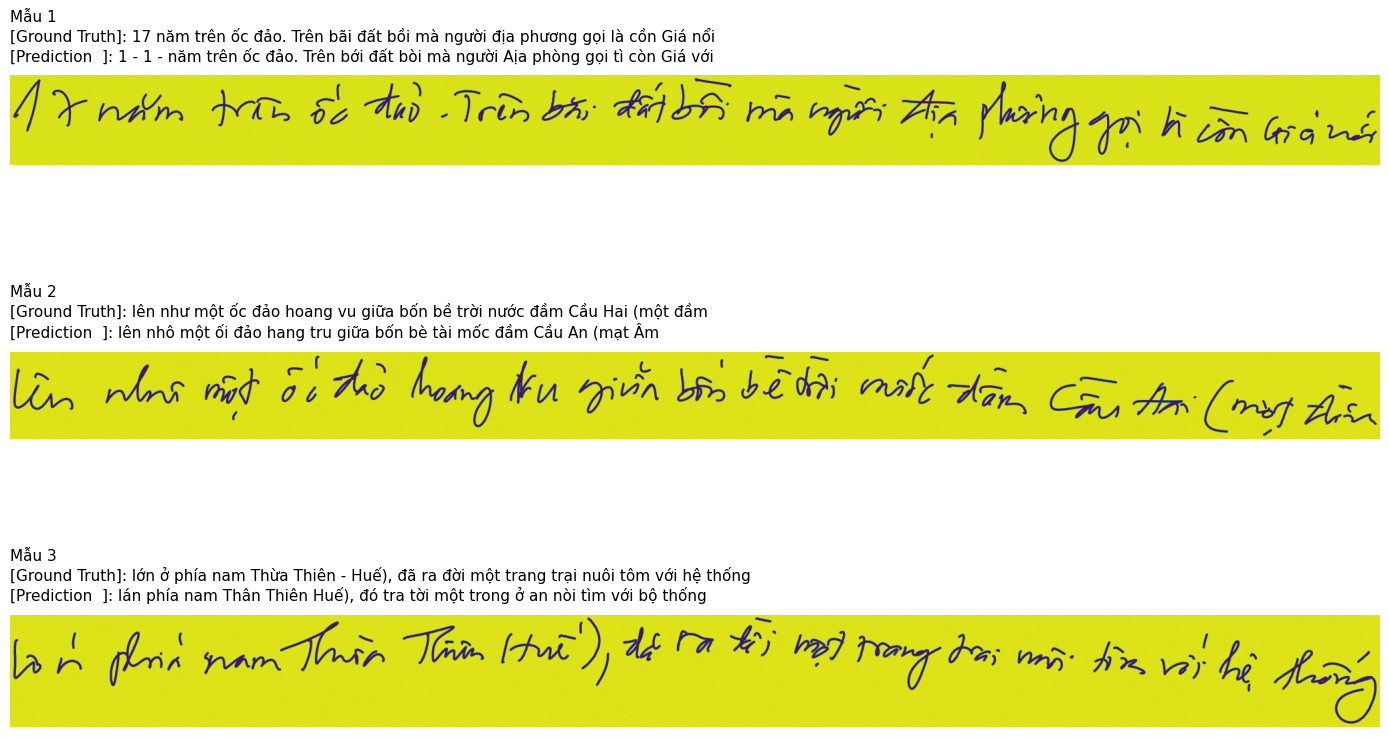

In [7]:
# [Phần II - Cell 7] Suy luận thực tế & Trực quan hóa ảnh tập Validation
import matplotlib.pyplot as plt
from PIL import Image
from vietocr.tool.predictor import Predictor
from vietocr.tool.config import Cfg

# 1. Khởi tạo Predictor với trọng số tốt nhất vừa train
predict_config = Cfg.load_config_from_name('vgg_transformer')
predict_config['device'] = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# Ưu tiên load best checkpoint, nếu không có thì lấy final checkpoint
weight_path = CONFIG_PATHS['checkpoint_dir'] / 'best_val_checkpoint.pth'
if not weight_path.exists():
    weight_path = CONFIG_PATHS['checkpoint_dir'] / 'vgg_transformer_final.pth'

predict_config['weights'] = str(weight_path)
predict_config['cnn']['pretrained'] = False
detector = Predictor(predict_config)

print(f"✓ Đã nạp thành công trọng số từ: {weight_path.name}\n")

# 2. Đọc 3 mẫu từ clean_val_line.txt
samples = []
with open(CONFIG_PATHS['clean_val_annotation'], 'r', encoding='utf-8') as f:
    for i in range(3):
        line = f.readline().strip()
        if line:
            img_p, gt_text = line.split('\t')
            samples.append((img_p, gt_text))

# 3. Trực quan hóa và suy luận
fig, axes = plt.subplots(len(samples), 1, figsize=(14, 3 * len(samples)))
if len(samples) == 1:
    axes = [axes]

for idx, (img_path, gt) in enumerate(samples):
    img = Image.open(img_path)
    pred_text = detector.predict(img)
    
    # Hiển thị ảnh
    axes[idx].imshow(img)
    axes[idx].axis('off')
    title = f"Mẫu {idx+1}\n[Ground Truth]: {gt}\n[Prediction  ]: {pred_text}"
    axes[idx].set_title(title, fontsize=11, loc='left', pad=10)
    
    print(f"--- Mẫu {idx+1} ---")
    print(f"Ground Truth: {gt}")
    print(f"Prediction  : {pred_text}\n")

plt.tight_layout()
plt.show()

In [8]:
# [Khảo sát thực tế] Quét toàn bộ tệp tin hiện diện trong /kaggle/working
import os
from pathlib import Path

working_dir = Path('/kaggle/working')

print(f"=== DANH SÁCH TỆP TIN THỰC TẾ TRONG {working_dir} ===")
found_files = []

for root, dirs, files in os.walk(working_dir):
    for f in files:
        full_path = Path(root) / f
        rel_path = full_path.relative_to(working_dir)
        size_mb = full_path.stat().st_size / (1024 * 1024)
        found_files.append((str(rel_path), size_mb))

if not found_files:
    print("Thư mục working hiện đang trống!")
else:
    for rel_path, size_mb in sorted(found_files, key=lambda x: x[0]):
        print(f" - {rel_path:<45} | Dung lượng: {size_mb:>7.2f} MB")

=== DANH SÁCH TỆP TIN THỰC TẾ TRONG /kaggle/working ===
 - .virtual_documents/__notebook_source__.ipynb  | Dung lượng:    0.01 MB
 - checkpoints/vgg_transformer_final.pth         | Dung lượng:  144.78 MB
 - clean_train_line.txt                          | Dung lượng:    1.15 MB
 - clean_val_line.txt                            | Dung lượng:    0.13 MB
 - train.log                                     | Dung lượng:    0.00 MB
 - train_data/data.mdb                           | Dung lượng:  726.54 MB
 - train_data/lock.mdb                           | Dung lượng:    0.01 MB
 - valid_data/data.mdb                           | Dung lượng:   86.90 MB
 - valid_data/lock.mdb                           | Dung lượng:    0.01 MB


In [9]:
# [Bảo hiểm lưu trữ] Đóng gói chính xác Checkpoint, Nhãn sạch và Cấu hình YAML
import zipfile
import yaml
from pathlib import Path

backup_zip = Path('/kaggle/working/vietocr_line_4k_backup.zip')

# 1. Xuất file config.yml để đảm bảo phiên sau nạp mô hình không bị lệch tham số
config_dump_path = Path('/kaggle/working/checkpoints/config_vgg_transformer.yml')
with open(config_dump_path, 'w', encoding='utf-8') as f:
    yaml.dump(dict(config), f, default_flow_style=False, allow_unicode=True)

# 2. Danh sách các tệp bắt buộc bảo toàn (tránh các file cache mdb nặng 800MB)
files_to_pack = [
    Path('/kaggle/working/checkpoints/vgg_transformer_final.pth'),
    config_dump_path,
    Path('/kaggle/working/clean_train_line.txt'),
    Path('/kaggle/working/clean_val_line.txt'),
]

print("=== TIẾN HÀNH ĐÓNG GÓI BẢO TOÀN ===")
with zipfile.ZipFile(backup_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for f in files_to_pack:
        if f.exists():
            size_mb = f.stat().st_size / (1024 * 1024)
            # Lưu giữ cấu trúc đường dẫn tương đối gọn gàng
            arc_name = f.name if f.parent == Path('/kaggle/working') else f"{f.parent.name}/{f.name}"
            zipf.write(f, arcname=arc_name)
            print(f"✓ Đã thêm: {arc_name:<35} ({size_mb:.2f} MB)")

print(f"\n=> HOÀN TẤT TỆP NÉN: {backup_zip.name} ({backup_zip.stat().st_size / (1024*1024):.2f} MB)")

=== TIẾN HÀNH ĐÓNG GÓI BẢO TOÀN ===
✓ Đã thêm: checkpoints/vgg_transformer_final.pth (144.78 MB)
✓ Đã thêm: checkpoints/config_vgg_transformer.yml (0.00 MB)
✓ Đã thêm: clean_train_line.txt                (1.15 MB)
✓ Đã thêm: clean_val_line.txt                  (0.13 MB)

=> HOÀN TẤT TỆP NÉN: vietocr_line_4k_backup.zip (135.36 MB)
